# Sprint 5: Vergleich der Datenstrategien und Machbarkeitstest mit Adzuna

## Projekt
Vorhersage von Gehaltsklassen in Stellenausschreibungen

## Ziel von Sprint 5
In Sprint 5 werden die beiden bisher verfolgten Datenstrategien systematisch verglichen:

1. das BA-Setup mit Proxy-Gehaltsklasse
2. das Adzuna-Setup mit direkteren Gehaltsfeldern

Ziel ist es, die Stärken und Schwächen beider Ansätze methodisch einzuordnen und daraus eine begründete Schlussfolgerung für das Gesamtprojekt abzuleiten.

Zusätzlich wird ein kleines Testmodell auf Basis der bereinigten Adzuna-Daten trainiert, um zu prüfen, ob sich mit den direkt verfügbaren Gehaltsfeldern grundsätzlich ein sinnvolles Machine-Learning-Setup aufbauen lässt.

## Importe

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

pd.set_option("display.max_columns", None)

## Datensätze laden

Für den Vergleich werden der finale Datensatz aus dem BA-Setup und der bereinigte Adzuna-Datensatz geladen.

In [15]:
df_ba = pd.read_csv("../data/jobs_with_salary_classes.csv")
df_adzuna = pd.read_csv("../data/adzuna_salary_clean.csv")

print("BA-Datensatz:", df_ba.shape)
print("Adzuna-Datensatz:", df_adzuna.shape)

BA-Datensatz: (1556, 15)
Adzuna-Datensatz: (637, 16)


## Überblick über beide Ansätze

Zunächst werden die wichtigsten Eigenschaften der beiden Datenstrategien tabellarisch gegenübergestellt.

In [16]:
comparison = pd.DataFrame({
    "Kriterium": [
        "Datenquelle",
        "Anzahl verwendbarer Anzeigen",
        "Zielvariable",
        "Zieltyp",
        "Abdeckung",
        "Hauptvorteil",
        "Hauptnachteil"
    ],
    "BA-Setup": [
        "Jobsuche-API + externe Entgelttabelle",
        len(df_ba),
        "gehaltsklasse",
        "Proxy-Klassifikation",
        "hoch",
        "große und stabile Datengrundlage",
        "kein direkt beobachtetes Gehalt"
    ],
    "Adzuna-Setup": [
        "Adzuna-API",
        len(df_adzuna),
        "salary_class",
        "direktere Gehaltsklassifikation",
        "niedrig",
        "direktere Gehaltsfelder",
        "starke Lücken und Ausreißer"
    ]
})

comparison

,Kriterium,BA-Setup,Adzuna-Setup
0,Datenquelle,Jobsuche-API + externe Entgelttabelle,Adzuna-API
1,Anzahl verwendbarer Anzeigen,1556,637
2,Zielvariable,gehaltsklasse,salary_class
3,Zieltyp,Proxy-Klassifikation,direktere Gehaltsklassifikation
4,Abdeckung,hoch,niedrig
5,Hauptvorteil,große und stabile Datengrundlage,direktere Gehaltsfelder
6,Hauptnachteil,kein direkt beobachtetes Gehalt,starke Lücken und Ausreißer


## Klassenverteilungen vergleichen

In [17]:
print("BA-Klassenverteilung:")
print(df_ba["gehaltsklasse"].value_counts())
print()

print("Adzuna-Klassenverteilung:")
print(df_adzuna["salary_class"].value_counts())

BA-Klassenverteilung:
gehaltsklasse
niedrig    522
hoch       518
mittel     516
Name: count, dtype: int64

Adzuna-Klassenverteilung:
salary_class
mittel     219
niedrig    215
hoch       203
Name: count, dtype: int64


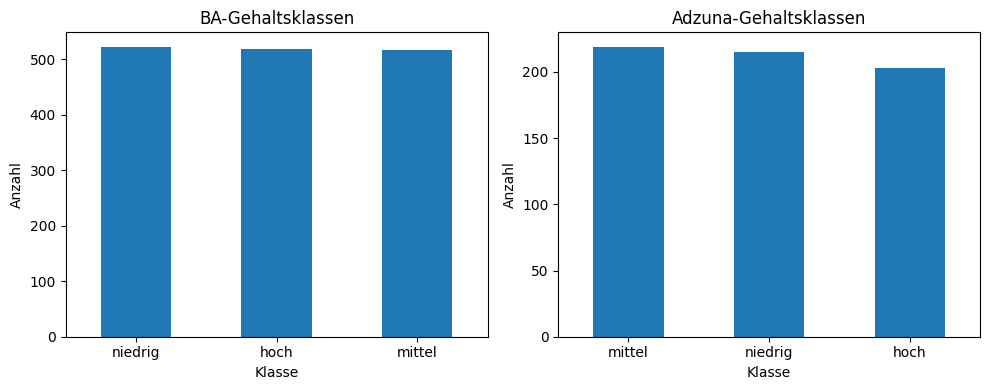

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df_ba["gehaltsklasse"].value_counts().plot(kind="bar", ax=axes[0], title="BA-Gehaltsklassen")
axes[0].set_xlabel("Klasse")
axes[0].set_ylabel("Anzahl")
axes[0].tick_params(axis="x", rotation=0)

df_adzuna["salary_class"].value_counts().plot(kind="bar", ax=axes[1], title="Adzuna-Gehaltsklassen")
axes[1].set_xlabel("Klasse")
axes[1].set_ylabel("Anzahl")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Methodische Gegenüberstellung

Das BA-Setup bietet eine deutlich größere und stabilere Datengrundlage, arbeitet jedoch mit einer konstruierten Proxy-Zielvariable. Das Adzuna-Setup liegt methodisch näher am eigentlichen Problem, weil direkte Gehaltsfelder vorhanden sind, leidet jedoch unter niedriger Abdeckung und Datenqualitätsproblemen.

Dadurch entsteht ein klarer methodischer Zielkonflikt:
- hohe Coverage versus direkteres Ziel
- stabile Datenbasis versus stärkere Nähe zum eigentlichen Business Problem

## Mini-Machbarkeitstest mit Adzuna

Im nächsten Schritt wird ein kleines Testmodell auf dem bereinigten Adzuna-Datensatz trainiert. Ziel ist nicht die vollständige Neuausrichtung des Projekts, sondern die Prüfung, ob sich auf Basis der direkt verfügbaren Salary-Daten grundsätzlich ein sinnvolles Klassifikationssetup aufbauen lässt.

## Features für Adzuna vorbereiten

Verwendet werden einfache und direkt verfügbare Merkmale:
- `title`
- `category_label`
- `location_display`

Diese Felder werden zu einem gemeinsamen Textfeld kombiniert.

In [19]:
df_adzuna["title"] = df_adzuna["title"].fillna("")
df_adzuna["category_label"] = df_adzuna["category_label"].fillna("")
df_adzuna["location_display"] = df_adzuna["location_display"].fillna("")

df_adzuna["text"] = (
    df_adzuna["title"] + " " +
    df_adzuna["category_label"] + " " +
    df_adzuna["location_display"]
)

df_adzuna[["title", "category_label", "location_display", "text"]].head()

,title,category_label,location_display,text
0,Data Engineer,Unknown,"Berlin, Deutschland","Data Engineer Unknown Berlin, Deutschland"
1,Data Engineer,IT-Stellen,"Berlin, Deutschland","Data Engineer IT-Stellen Berlin, Deutschland"
2,Data Engineer (gn),Unknown,"Hammerbrook, Hamburg","Data Engineer (gn) Unknown Hammerbrook, Hamburg"
3,Cloud & Data Engineer (gn),Unknown,"Hammerbrook, Hamburg",Cloud & Data Engineer (gn) Unknown Hammerbrook...
4,Cloud & Data Engineer (gn),Unknown,"Hammerbrook, Hamburg",Cloud & Data Engineer (gn) Unknown Hammerbrook...


## Trainings- und Testdaten aufteilen

In [20]:
X = df_adzuna["text"]
y = df_adzuna["salary_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-Größe:", len(X_train))
print("Test-Größe:", len(X_test))

Train-Größe: 509
Test-Größe: 128


## Baseline-Modell für Adzuna

In [21]:
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train.to_frame(), y_train)

y_pred_baseline = baseline_model.predict(X_test.to_frame())

print("Baseline Accuracy:", round(accuracy_score(y_test, y_pred_baseline), 3))
print()
print(classification_report(y_test, y_pred_baseline, zero_division=0))

Baseline Accuracy: 0.344

              precision    recall  f1-score   support

        hoch       0.00      0.00      0.00        41
      mittel       0.34      1.00      0.51        44
     niedrig       0.00      0.00      0.00        43

    accuracy                           0.34       128
   macro avg       0.11      0.33      0.17       128
weighted avg       0.12      0.34      0.18       128



## Logistic Regression auf Adzuna

In [22]:
adzuna_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=3000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000))
])

adzuna_model.fit(X_train, y_train)
y_pred_adzuna = adzuna_model.predict(X_test)

print("Adzuna Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_adzuna), 3))
print()
print(classification_report(y_test, y_pred_adzuna))

Adzuna Logistic Regression Accuracy: 0.594

              precision    recall  f1-score   support

        hoch       0.57      0.59      0.58        41
      mittel       0.55      0.64      0.59        44
     niedrig       0.69      0.56      0.62        43

    accuracy                           0.59       128
   macro avg       0.60      0.59      0.59       128
weighted avg       0.60      0.59      0.59       128



## Random Forest auf Adzuna

Zusätzlich zur Logistic Regression wird auch ein Random-Forest-Klassifikator getestet. Dadurch lässt sich prüfen, ob ein flexibleres nichtlineares Modell auf dem kleinen Adzuna-Datensatz bessere Ergebnisse erzielt.

In [24]:
adzuna_rf_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=3000, ngram_range=(1, 2))),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])

adzuna_rf_model.fit(X_train, y_train)
y_pred_adzuna_rf = adzuna_rf_model.predict(X_test)

print("Adzuna Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_adzuna_rf), 3))
print()
print(classification_report(y_test, y_pred_adzuna_rf))

Adzuna Random Forest Accuracy: 0.555

              precision    recall  f1-score   support

        hoch       0.55      0.56      0.55        41
      mittel       0.53      0.59      0.56        44
     niedrig       0.59      0.51      0.55        43

    accuracy                           0.55       128
   macro avg       0.56      0.55      0.55       128
weighted avg       0.56      0.55      0.55       128



## Cross-Validation auf Adzuna

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

adzuna_cv_scores = cross_val_score(
    adzuna_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Adzuna Logistic Regression CV Accuracy:", np.round(adzuna_cv_scores, 3))
print("Mittelwert:", round(adzuna_cv_scores.mean(), 3))
print("Standardabweichung:", round(adzuna_cv_scores.std(), 3))

Adzuna Logistic Regression CV Accuracy: [0.609 0.672 0.598 0.63  0.614]
Mittelwert: 0.625
Standardabweichung: 0.026


In [26]:
adzuna_rf_cv_scores = cross_val_score(
    adzuna_rf_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Adzuna Random Forest CV Accuracy:", np.round(adzuna_rf_cv_scores, 3))
print("Mittelwert:", round(adzuna_rf_cv_scores.mean(), 3))
print("Standardabweichung:", round(adzuna_rf_cv_scores.std(), 3))

Adzuna Random Forest CV Accuracy: [0.555 0.602 0.567 0.551 0.598]
Mittelwert: 0.575
Standardabweichung: 0.021


## Vergleich der Baseline mit dem Adzuna-Testmodell

In [29]:
adzuna_results = pd.DataFrame({
    "Modell": ["Baseline", "Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_adzuna),
        accuracy_score(y_test, y_pred_adzuna_rf)
    ]
})

adzuna_results

,Modell,Accuracy
0,Baseline,0.343750
1,Logistic Regression,0.593750
2,Random Forest,0.554688


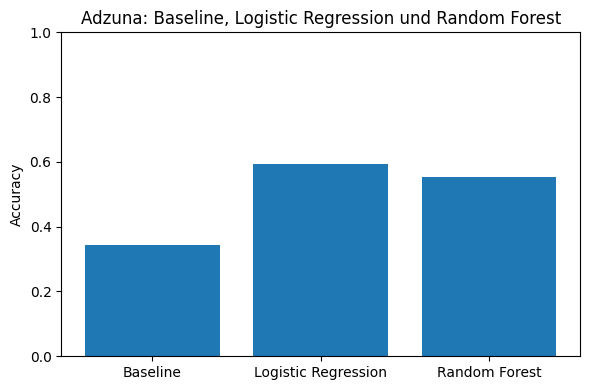

In [34]:
plt.figure(figsize=(6, 4))
plt.bar(adzuna_results["Modell"], adzuna_results["Accuracy"])
plt.title("Adzuna: Baseline, Logistic Regression und Random Forest")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [31]:
adzuna_cv_results = pd.DataFrame({
    "Modell": ["Logistic Regression", "Random Forest"],
    "CV_Mean_Accuracy": [
        adzuna_cv_scores.mean(),
        adzuna_rf_cv_scores.mean()
    ],
    "CV_Std": [
        adzuna_cv_scores.std(),
        adzuna_rf_cv_scores.std()
    ]
})

adzuna_cv_results

,Modell,CV_Mean_Accuracy,CV_Std
0,Logistic Regression,0.624754,0.025647
1,Random Forest,0.574557,0.021440


## Direkter Vergleich: BA-Setup vs. Adzuna-Setup

Im letzten Schritt werden nicht einfach rohe Accuracy-Werte gegeneinander ausgespielt, da die beiden Aufgaben auf unterschiedlichen Datengrundlagen beruhen. Stattdessen wird eingeordnet, wie sich beide Ansätze methodisch unterscheiden.

In [32]:
final_comparison = pd.DataFrame({
    "Aspekt": [
        "Verwendbare Datenmenge",
        "Zielvariable",
        "Nähe zum eigentlichen Gehaltsproblem",
        "Datenqualität",
        "Abdeckung",
        "Eignung als Hauptansatz"
    ],
    "BA-Setup": [
        "hoch",
        "Proxy-Gehaltsklasse",
        "mittel",
        "stabil",
        "hoch",
        "hoch"
    ],
    "Adzuna-Setup": [
        "niedrig",
        "direktere salary_class",
        "hoch",
        "eingeschränkt",
        "niedrig",
        "mittel bis niedrig"
    ]
})

final_comparison

,Aspekt,BA-Setup,Adzuna-Setup
0,Verwendbare Datenmenge,hoch,niedrig
1,Zielvariable,Proxy-Gehaltsklasse,direktere salary_class
2,Nähe zum eigentlichen Gehaltsproblem,mittel,hoch
3,Datenqualität,stabil,eingeschränkt
4,Abdeckung,hoch,niedrig
5,Eignung als Hauptansatz,hoch,mittel bis niedrig


## Interpretation des Mini-Testmodells

Der kleine Machbarkeitstest mit Adzuna dient nur als Zusatzanalyse. Er soll zeigen, ob sich mit den vorhandenen Feldern `title`, `category_label` und `location_display` grundsätzlich ein Klassifikationsmodell für direktere Gehaltsklassen aufbauen lässt.

Der Vergleich von Logistic Regression und Random Forest zeigt, ob auf dem kleinen und bereinigten Adzuna-Datensatz eher ein lineares oder ein flexibleres Modell besser funktioniert. Selbst wenn die Modelle brauchbare Ergebnisse erzielen, bleibt die wichtigste Einschränkung die geringe Datenbasis. Dadurch ist Adzuna in dieser Arbeit eher als methodisch interessante Ergänzung zu verstehen und nicht als belastbarer Ersatz des bisherigen Hauptansatzes.

## Fazit von Sprint 5

Sprint 5 verbindet die beiden im Projekt verfolgten Datenstrategien miteinander. Der Vergleich zeigt, dass das BA-Setup trotz seiner Proxy-Zielvariable für diese Arbeit die tragfähigere Hauptlösung bleibt, weil es deutlich mehr verwendbare Daten und eine stabilere Grundlage für die Modellierung bietet.

Gleichzeitig zeigt der explorative Adzuna-Ansatz, dass Datenquellen mit direkteren Gehaltsfeldern grundsätzlich attraktiver für das ursprüngliche Business Problem wären. In der praktischen Anwendung sind sie in diesem Projekt jedoch durch geringe Abdeckung, Dubletten und Plausibilitätsprobleme begrenzt.

Damit liefert Sprint 5 eine begründete methodische Schlussentscheidung: Für die vorliegende Arbeit ist das BA-Setup der geeignetere Hauptansatz, während Adzuna als ergänzende Machbarkeitsanalyse und als Ausblick auf eine mögliche Weiterentwicklung dient.